# Практическая работа 3: Научные вычисления с SciPy

**Библиотека:** `scipy` — стандарт для научных вычислений в Python.

В этой работе разберём три ключевых подмодуля:
| Модуль | Задача |
|---|---|
| `scipy.interpolate` | Сглаживание зашумлённых данных |
| `scipy.optimize` | Подбор параметров модели |
| `scipy.integrate` | Численное интегрирование |

**Сценарий:** у нас есть датчик, сигнал которого описывается затухающими колебаниями:

$$f(x) = A \cdot \sin(\omega x) \cdot e^{-\lambda x}$$

Параметры $A$, $\omega$, $\lambda$ у каждого датчика немного разные. Наша задача — восстановить их по зашумлённым измерениям.

## Импорт библиотек

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
from scipy.optimize import curve_fit
from scipy.integrate import quad

## Генерация данных

Имитируем сигнал датчика: считаем «истинный» сигнал и добавляем гауссовский шум.

> В реальной задаче `x` и `y_noisy` — это данные с прибора. Здесь мы их генерируем сами, чтобы потом проверить точность восстановления параметров.

In [2]:
np.random.seed(0)  # фиксируем seed для воспроизводимости

# Временные точки измерений
x = np.linspace(0, 6, 40)

# Истинные параметры датчика (в реальной жизни нам они неизвестны)
A_true   = 3.0   # амплитуда
w_true   = 2.0   # угловая частота
lam_true = 0.4   # коэффициент затухания

# Идеальный сигнал без шума
y_true = A_true * np.sin(w_true * x) * np.exp(-lam_true * x)

# Зашумлённые показания датчика (шум ≈ погрешность измерений)
noise   = np.random.normal(loc=0, scale=0.2, size=x.shape)
y_noisy = y_true + noise

# Плотная сетка для отрисовки гладких кривых
x_fine = np.linspace(0, 6, 300)

## Задание 1: Интерполяция — `scipy.interpolate`

**Цель:** сгладить шум и нащупать форму сигнала, не зная его уравнения.

`UnivariateSpline` строит кусочно-полиномиальную кривую через точки.
Параметр `s` управляет сглаживанием:
- `s=0` — кривая проходит точно через каждую точку (переобучение на шум)
- `s>0` — кривая сглаживает шум (чем больше `s`, тем грубее)

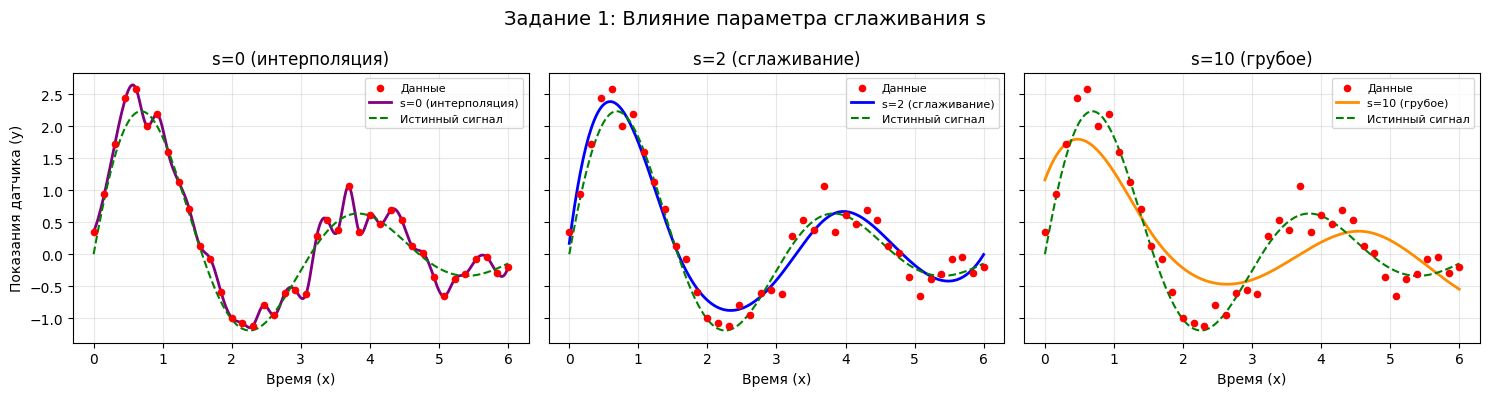

In [3]:
# Строим сплайн с разными уровнями сглаживания
spline_exact  = UnivariateSpline(x, y_noisy, s=0)   # s=0: через все точки
spline_smooth = UnivariateSpline(x, y_noisy, s=2)   # s=2: умеренное сглаживание
spline_rough  = UnivariateSpline(x, y_noisy, s=10)  # s=10: сильное сглаживание

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, spline, label, color in zip(
    axes,
    [spline_exact, spline_smooth, spline_rough],
    ['s=0 (интерполяция)', 's=2 (сглаживание)', 's=10 (грубое)'],
    ['purple', 'blue', 'darkorange']
):
    ax.scatter(x, y_noisy, color='red', s=20, label='Данные', zorder=5)
    ax.plot(x_fine, spline(x_fine), color=color, linewidth=2, label=label)
    ax.plot(x_fine, A_true * np.sin(w_true * x_fine) * np.exp(-lam_true * x_fine),
            'g--', linewidth=1.5, label='Истинный сигнал')
    ax.set_title(label)
    ax.set_xlabel('Время (x)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Показания датчика (y)')
fig.suptitle('Задание 1: Влияние параметра сглаживания s', fontsize=14)
plt.tight_layout()
plt.show()

**Вопрос:** в чём разница между интерполяцией (`s=0`) и аппроксимацией (`s>0`) для зашумлённых данных?

> *Напишите вывод здесь:*

## Задание 2: Подгонка кривой — `scipy.optimize`

**Цель:** зная форму модели, найти её параметры $(A, \omega, \lambda)$, которые лучше всего описывают данные.

`curve_fit` минимизирует сумму квадратов отклонений между моделью и данными.

> **Важно:** параметр `p0` — начальное приближение. Если поставить `[0, 0, 0]`, алгоритм может не сойтись. Используйте разумные оценки, полученные из графика.

In [4]:
# Определяем функцию модели — именно такую форму мы ищем
def model(x, A, omega, lam):
    return A * np.sin(omega * x) * np.exp(-lam * x)

# Начальное приближение параметров (берём из здравого смысла / графика)
p0 = [2.0, 1.5, 0.3]

# popt — найденные оптимальные параметры
# pcov — ковариационная матрица (чем меньше диагональ, тем точнее оценка)
popt, pcov = curve_fit(model, x, y_noisy, p0=p0)
A_fit, w_fit, lam_fit = popt

print("Сравнение параметров:")
print(f"  Истинные:  A={A_true:.3f}, ω={w_true:.3f}, λ={lam_true:.3f}")
print(f"  Найденные: A={A_fit:.3f}, ω={w_fit:.3f}, λ={lam_fit:.3f}")

# MSE — средняя квадратичная ошибка между моделью и данными
mse = np.mean((y_noisy - model(x, *popt))**2)
print(f"\nMSE подобранной модели: {mse:.4f}")

Сравнение параметров:
  Истинные:  A=3.000, ω=2.000, λ=0.400
  Найденные: A=3.290, ω=1.980, λ=0.435

MSE подобранной модели: 0.0452


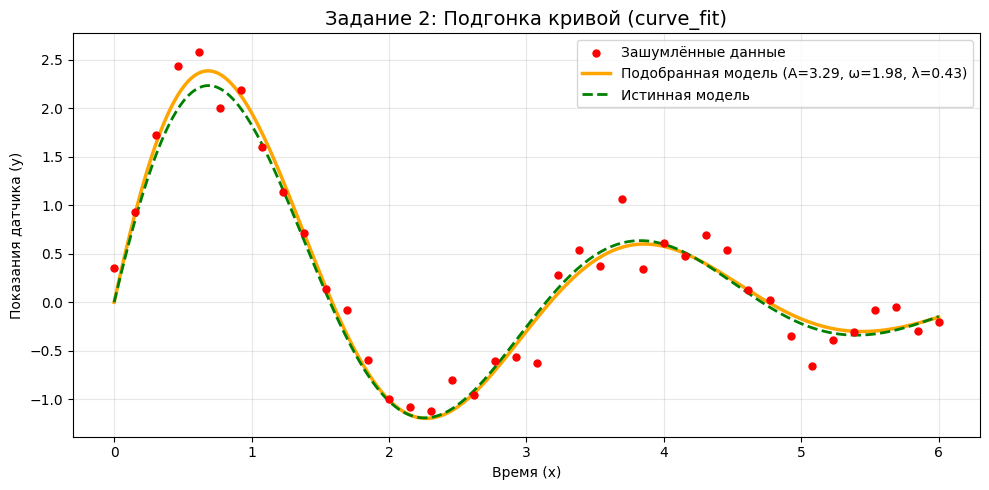

In [5]:
# Визуализация результата подгонки
plt.figure(figsize=(10, 5))
plt.scatter(x, y_noisy, color='red', s=25, label='Зашумлённые данные', zorder=5)
plt.plot(x_fine, model(x_fine, *popt), color='orange',
         linewidth=2.5, label=f'Подобранная модель (A={A_fit:.2f}, ω={w_fit:.2f}, λ={lam_fit:.2f})')
plt.plot(x_fine, A_true * np.sin(w_true * x_fine) * np.exp(-lam_true * x_fine),
         'g--', linewidth=2, label='Истинная модель')
plt.title('Задание 2: Подгонка кривой (curve_fit)', fontsize=14)
plt.xlabel('Время (x)')
plt.ylabel('Показания датчика (y)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Эксперимент: влияние начального приближения `p0`

Попробуйте заменить `p0` на плохие значения и посмотрите, что происходит.

In [6]:
# Плохое начальное приближение
p0_bad = [0.1, 0.1, 0.1]

try:
    popt_bad, _ = curve_fit(model, x, y_noisy, p0=p0_bad, maxfev=2000)
    mse_bad = np.mean((y_noisy - model(x, *popt_bad))**2)
    print(f"Плохое p0  → A={popt_bad[0]:.3f}, ω={popt_bad[1]:.3f}, λ={popt_bad[2]:.3f}, MSE={mse_bad:.4f}")
except RuntimeError as e:
    print(f"Алгоритм не сошёлся: {e}")

print(f"Хорошее p0 → A={A_fit:.3f}, ω={w_fit:.3f}, λ={lam_fit:.3f}, MSE={mse:.4f}")

Плохое p0  → A=3.290, ω=1.980, λ=0.435, MSE=0.0452
Хорошее p0 → A=3.290, ω=1.980, λ=0.435, MSE=0.0452


**Вопрос:** как начальное приближение `p0` влияет на результат подбора параметров?

> *Напишите вывод здесь:*

## Задание 3: Численное интегрирование — `scipy.integrate`

**Цель:** вычислить площадь под кривой и сравнить подобранную модель с истинной.

`quad(func, a, b)` возвращает кортеж `(значение, оценка_ошибки)`.

In [7]:
# Интегрируем подобранную модель на [0, 6]
area_fit, err_fit = quad(lambda x: model(x, *popt), 0, 6)

# Интегрируем истинную модель на том же интервале
area_true, err_true = quad(
    lambda x: A_true * np.sin(w_true * x) * np.exp(-lam_true * x), 0, 6
)

print("Численное интегрирование на [0, 6]:")
print(f"  Истинная модель:    {area_true:.4f}  (погрешность quad: {err_true:.2e})")
print(f"  Подобранная модель: {area_fit:.4f}  (погрешность quad: {err_fit:.2e})")
print(f"  Отклонение:         {abs(area_fit - area_true):.4f}")

Численное интегрирование на [0, 6]:
  Истинная модель:    1.3459  (погрешность quad: 3.59e-10)
  Подобранная модель: 1.5106  (погрешность quad: 6.89e-10)
  Отклонение:         0.1647


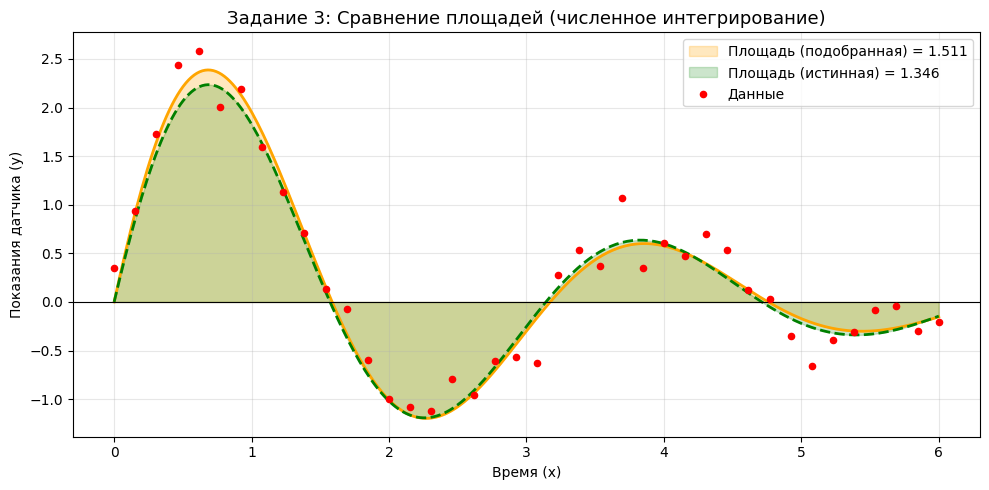

In [8]:
# Визуализация: закрашиваем площадь под обеими кривыми
y_fit_fine  = model(x_fine, *popt)
y_true_fine = A_true * np.sin(w_true * x_fine) * np.exp(-lam_true * x_fine)

plt.figure(figsize=(10, 5))
plt.fill_between(x_fine, y_fit_fine, alpha=0.25, color='orange', label=f'Площадь (подобранная) = {area_fit:.3f}')
plt.fill_between(x_fine, y_true_fine, alpha=0.2, color='green', label=f'Площадь (истинная) = {area_true:.3f}')
plt.plot(x_fine, y_fit_fine,  color='orange', linewidth=2)
plt.plot(x_fine, y_true_fine, 'g--', linewidth=2)
plt.scatter(x, y_noisy, color='red', s=20, zorder=5, label='Данные')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Задание 3: Сравнение площадей (численное интегрирование)', fontsize=13)
plt.xlabel('Время (x)')
plt.ylabel('Показания датчика (y)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Вывод:** насколько подобранная модель соответствует истинной? Чем объясняется расхождение?

> *Напишите вывод здесь:*